In [104]:
# fig, ax = plt.subplots(figsize= (20,6))

# ax.set_title('Preços', fontsize=16)
# ax.set_ylabel('Valor', fontsize=16)

# ax = dados['precos'].plot()

In [105]:
import seaborn as sns
import numpy as np 
import pandas as pd
dados = pd.read_csv('dados/HousePrices_HalfMil.csv', sep = ';')
dados

,precos,area,garagem,banheiros,lareira,marmore,andares
0,51875,25,3,4,3,0,1
1,17875,35,1,3,1,0,0
2,47075,195,2,4,2,0,0
3,38575,33,2,2,1,0,1
4,33775,11,2,3,0,0,1
...,...,...,...,...,...,...,...
995,29150,48,1,5,4,0,0
996,43550,112,2,2,3,0,1
997,56575,185,3,4,4,0,1
998,56075,185,2,3,1,0,1


### Andares que nao possui mais de 1 andar vende mais ✍️

In [106]:
dados.andares.value_counts()

0    515
1    485
Name: andares, dtype: int64

In [107]:
dados.describe().round(4)

,precos,area,garagem,banheiros,lareira,marmore,andares
count,1000.0000,1000.000,1000.0000,1000.0000,1000.0000,1000.0000,1000.000
mean,41985.6000,124.326,2.0090,3.0000,2.0340,0.3310,0.485
std,12140.3854,72.390,0.8134,1.4297,1.4188,0.4708,0.500
min,13150.0000,1.000,1.0000,1.0000,0.0000,0.0000,0.000
25%,33112.5000,60.750,1.0000,2.0000,1.0000,0.0000,0.000
50%,41725.0000,123.000,2.0000,3.0000,2.0000,0.0000,0.000
75%,51175.0000,187.000,3.0000,4.0000,3.0000,1.0000,1.000
max,73675.0000,249.000,3.0000,5.0000,4.0000,1.0000,1.000


In [108]:
dados.corr().round(4)

,precos,area,garagem,banheiros,lareira,marmore,andares
precos,1.0000,0.1177,0.1028,0.1244,0.1072,0.4308,0.6315
area,0.1177,1.0000,-0.0075,-0.0114,0.0121,-0.0153,-0.0180
garagem,0.1028,-0.0075,1.0000,0.0671,0.0605,-0.0156,-0.0206
banheiros,0.1244,-0.0114,0.0671,1.0000,0.0484,-0.0253,-0.0182
lareira,0.1072,0.0121,0.0605,0.0484,1.0000,0.0296,-0.0035
marmore,0.4308,-0.0153,-0.0156,-0.0253,0.0296,1.0000,-0.0065
andares,0.6315,-0.0180,-0.0206,-0.0182,-0.0035,-0.0065,1.0000


In [109]:
sns.set_palette('Accent')
sns.set_style('darkgrid')

In [110]:
%matplotlib inline
import matplotlib.pyplot as plt

# Analizando preços!! 

Text(0.5, 0, 'Garagem')

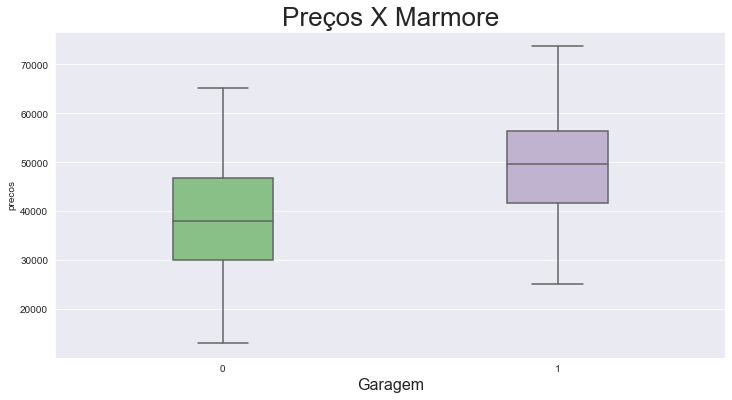

In [111]:
ax = sns.boxplot(y= 'precos', x= 'marmore', data=dados, orient='v', width= 0.30)

ax.figure.set_size_inches(12,6)

ax.set_title('Preços X Marmore', fontsize=26)
ax.set_xlabel('Garagem', fontsize=16)

Text(0.5, 0, 'Garagem')

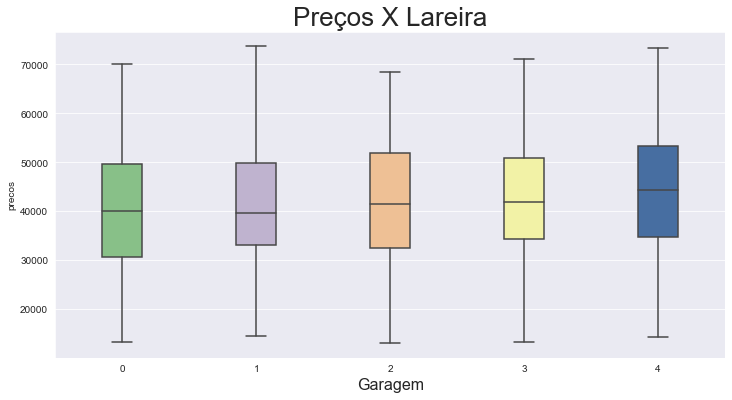

In [112]:
ax = sns.boxplot(y= 'precos', x= 'lareira', data=dados, orient='v', width= 0.30)

ax.figure.set_size_inches(12,6)

ax.set_title('Preços X Lareira', fontsize=26)
ax.set_xlabel('Garagem', fontsize=16)

Text(0.5, 0, 'Garagem')

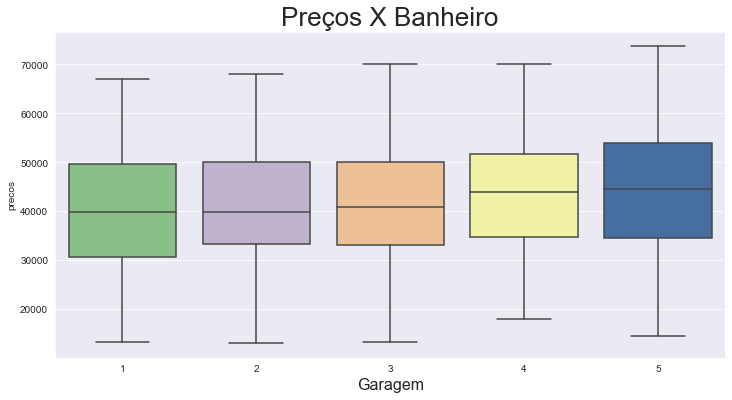

In [113]:
ax = sns.boxplot(y= 'precos', x= 'banheiros', data=dados, orient='v')

ax.figure.set_size_inches(12,6)

ax.set_title('Preços X Banheiro', fontsize=26)
ax.set_xlabel('Garagem', fontsize=16)

Text(0.5, 0, 'Garagem')

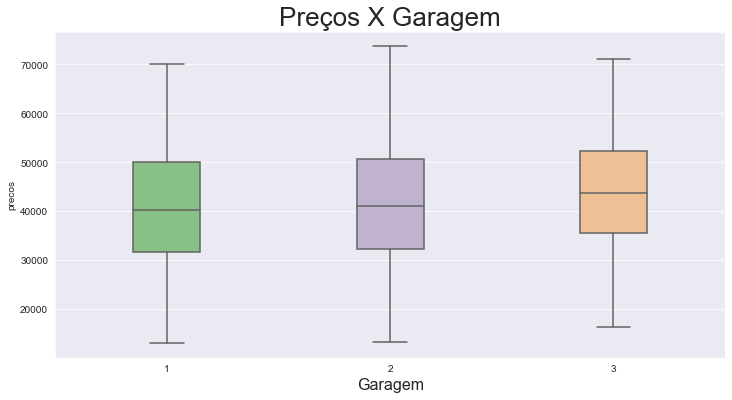

In [114]:
ax = sns.boxplot(y= 'precos', x= 'garagem', data=dados, orient='v', width= 0.30)

ax.figure.set_size_inches(12,6)

ax.set_title('Preços X Garagem', fontsize=26)
ax.set_xlabel('Garagem', fontsize=16)

Text(0.5, 0, 'Andares')

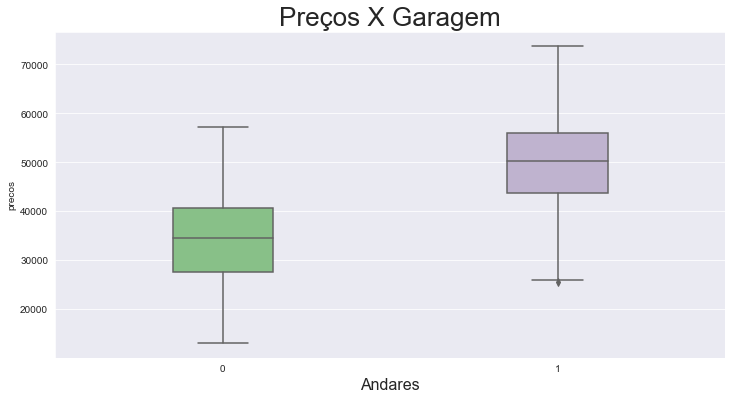

In [115]:
ax = sns.boxplot(y= 'precos', x= 'andares', data=dados, orient='v', width= 0.30)

ax.figure.set_size_inches(12,6)

ax.set_title('Preços X Garagem', fontsize=26)
ax.set_xlabel('Andares', fontsize=16)

C:\Users\vitor\Colab\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='precos', ylabel='Density'>

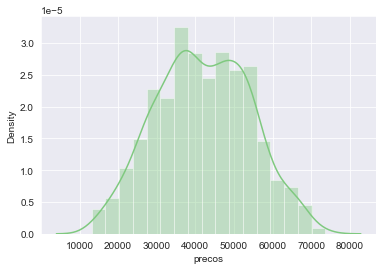

In [116]:
ax = sns.distplot(dados['precos'])
ax

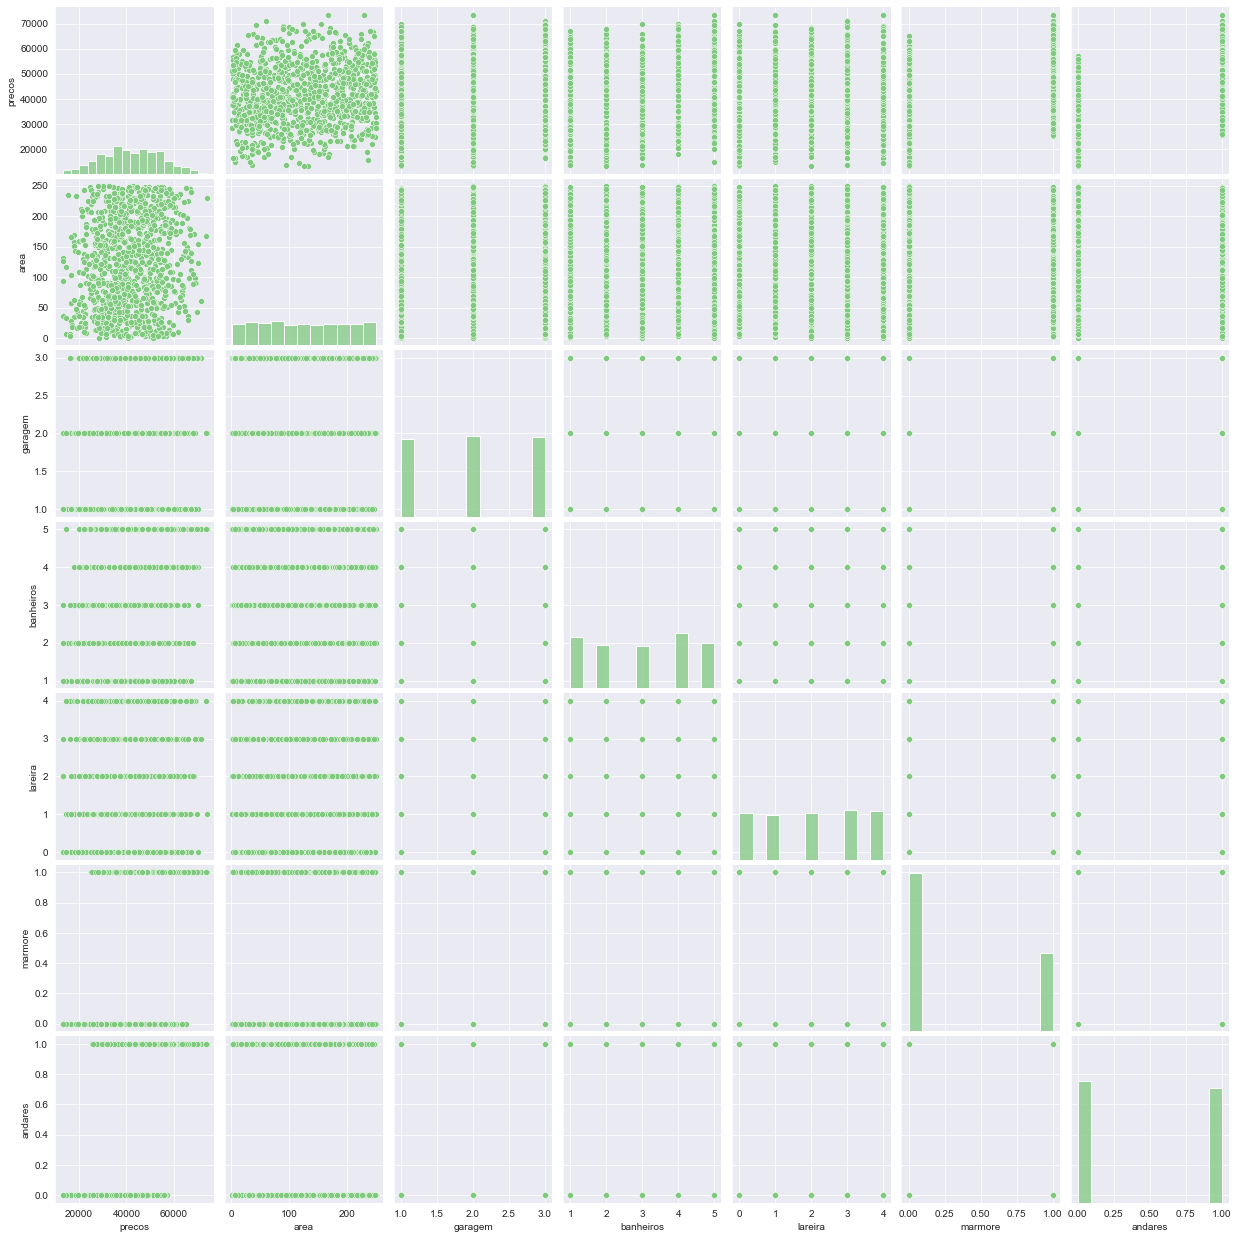

In [117]:
ax = sns.pairplot(dados)

Mais de um andar os preços sairam mais caros


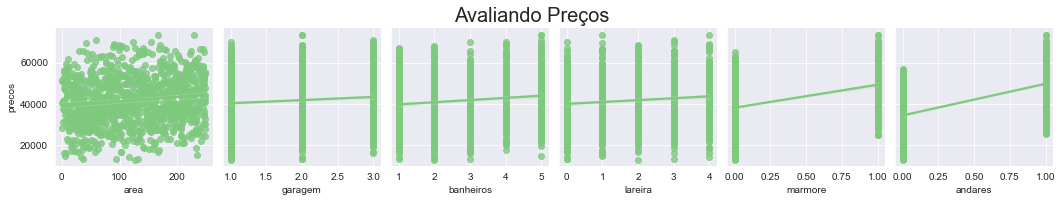

In [118]:
ax = sns.pairplot(dados, y_vars='precos', x_vars=['area', 'garagem', 'banheiros', 'lareira', 'marmore', 'andares'], kind= 'reg')
ax.fig.suptitle('Avaliando Preços', fontsize=20, y=1.08)
print('Mais de um andar os preços sairam mais caros')

In [119]:
y = dados['precos']
x = dados[['andares', 'area', 'garagem', 'banheiros', 'lareira', 'marmore']]

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, test_size=0.3, random_state=2811)

In [122]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

### Treina o Modelo 

In [123]:
modelo = LinearRegression()

modelo.fit(treino_x, treino_y)
print('{}'.format(modelo.score(treino_x, treino_y).round(2)))

0.64


### Previsoes

In [124]:
y_previsoes = modelo.predict(teste_x)

print('%s' % metrics.r2_score(teste_y, y_previsoes).round(2))

0.67


In [125]:
avaliacao = (teste_x['andares'] == 0) & (teste_x['area'] <= 50)
n1 = teste_x[avaliacao]
n1.head(2)

,andares,area,garagem,banheiros,lareira,marmore
889,0,47,2,2,3,0
812,0,13,3,2,2,1


In [126]:
entrada = n1[n1.index == 889]
entrada

,andares,area,garagem,banheiros,lareira,marmore
889,0,47,2,2,3,0


## Valor conforme os dados mostrado !💰 
### Andares menor do que 1
### Area == 47
### garagem == 2
### banheiros == 2 
### lareira == 3
### marmore == 0

## Valor Previsto da Casa 

In [127]:
modelo.predict(entrada)[0]

28507.476856894362

In [128]:
valor = n1[n1.index == 812]
valor

,andares,area,garagem,banheiros,lareira,marmore
812,0,13,3,2,2,1


## Valor conforme os dados mostrado !💰 
### Andares menor do que 1
### Area == 13
### garagem == 3
### banheiros == 2
### lareira == 2
### marmore == 1

## Valor Previsto da Casa 

In [129]:
modelo.predict(valor)[0]

39948.634864380074

In [130]:
EQM = metrics.mean_squared_error(teste_y, y_previsoes).round(2) #media dos quadrado de erros_sq
REQM = np.sqrt(metrics.mean_squared_error(teste_y, y_previsoes).round(2))
R2 = metrics.r2_score(teste_y, y_previsoes).round(2)

pd.DataFrame([EQM, REQM, R2], ['EQM', 'REQM', 'R²'], columns= ['Metricas'])

,Metricas
EQM,5.019702e+07
REQM,7.084985e+03
R²,6.700000e-01


## Valores Medio

In [131]:
modelo.intercept_

19186.25691690074

In [132]:
modelo.coef_

array([14861.5964676 ,    24.56333637,  1803.50885155,  1291.41973815,
         658.96198367, 11131.76457634])

In [133]:
x.columns

Index(['andares', 'area', 'garagem', 'banheiros', 'lareira', 'marmore'], dtype='object')

In [134]:
index =['Preços', 'Andares', 'Area','Garagem','Banheiros','Lareira', 'Marmore']

## Valor Medio das Variaveis ✍️

In [135]:
pd.DataFrame(data = np.append(modelo.intercept_, modelo.coef_), index=index, columns =['Parametros'])

,Parametros
Preços,19186.256917
Andares,14861.596468
Area,24.563336
Garagem,1803.508852
Banheiros,1291.419738
Lareira,658.961984
Marmore,11131.764576
